ResilienceLevel
1    5469
2    2997
3     194
Name: count, dtype: int64


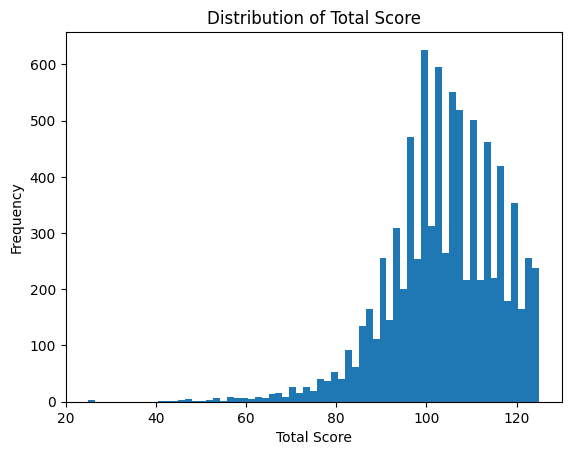

     PublicID  TotalScore  ResilienceLevel
0      00004O       102.0                1
1      00007I       106.0                1
2      00008G       107.0                1
3      00015J       120.0                1
4      00016H        97.0                2
...       ...         ...              ...
8655   17349I        98.0                2
8656   17350A       119.0                1
8657   17351V       104.0                1
8658   17352T       100.0                2
8659   17354P       117.0                1

[8660 rows x 3 columns]


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path 

# csv_file = Path(__file__).with_name('V2I.CSV')  # Load the CSV file
df = pd.read_csv('V2I.csv')  # Read the CSV into a DataFrame

def compute_resilience_score(row):
    total_score = row[['V2IA{:02d}'.format(i) for i in range(1, 26)]].sum()
    
    return pd.Series({
        'TotalScore': total_score, #give distribution of this 
    })

def resilience_level(score):
    if score <= 75:
        return 3
    elif score <= 100:
        return 2
    else:
        return 1

df = df.join(df.apply(compute_resilience_score, axis=1))
df['ResilienceLevel'] = df['TotalScore'].apply(resilience_level)

# Select only the necessary columns
df = df[['PublicID', 'TotalScore', 'ResilienceLevel']]
df['TotalScore'].describe()
# Get counts of individuals in each resilience level
resilience_counts = df['ResilienceLevel'].value_counts()
print(resilience_counts)

# Plot histogram of total score
plt.hist(df['TotalScore'], bins='auto')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.title('Distribution of Total Score')
plt.show()

print(df)
 # dont make cut off not informative
    
scoring_df = df[['ResilienceLevel', 'PublicID']]


In [54]:
df['TotalScore'].describe()


count    8660.000000
mean      103.921824
std        12.293125
min        25.000000
25%        97.000000
50%       104.000000
75%       113.000000
max       125.000000
Name: TotalScore, dtype: float64

In [55]:

import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns

df = pd.read_csv('V1E.CSV', encoding='ISO-8859-1')  
# Select relevant columns
relevant_columns = ['V1EA01', 'V1EA02a','V1EA02b','V1EA02c','V1EA02d','V1EA02e','V1EA02f',
                    'V1EA02g','V1EA02h','V1EA02i','V1EA02j','V1EA02k','V1EA02l']
df_relevant = df[['PublicID'] + relevant_columns]

# Create a new column 'item_average' to store the mean of each row across the selected columns
df_relevant['stress_average'] = df_relevant[relevant_columns].mean(axis=1)

# Now the 'item_average' for each 'PublidID' is in the 'item_average' column
print(df_relevant[['PublicID', 'stress_average']])


# Create a histogram
# plt.hist(df_relevant['stress_average'], bins=30, alpha=0.5, color='g')

# plt.title('Distribution of Stress Average Scores')
# plt.xlabel('Item Average Score')
# plt.ylabel('Frequency')

# Show the plot
# plt.show()

     PublicID  stress_average
0      00004O        1.846154
1      00007I        1.538462
2      00008G        2.076923
3      00015J        1.692308
4      00016H        2.000000
...       ...             ...
8165   17349I        1.461538
8166   17350A        1.384615
8167   17351V        1.384615
8168   17352T        1.538462
8169   17354P        1.461538

[8170 rows x 2 columns]


C:\Users\91799\AppData\Local\Temp\ipykernel_21680\79861644.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_relevant['stress_average'] = df_relevant[relevant_columns].mean(axis=1)


In [56]:
scoring_df = pd.merge(scoring_df, df_relevant[['PublicID','stress_average']], on='PublicID', how='inner')


In [57]:
df_relevant['stress_average'].describe()

count    8169.000000
mean        1.524365
std         0.317417
min         1.000000
25%         1.307692
50%         1.461538
75%         1.692308
max         3.000000
Name: stress_average, dtype: float64

In [58]:
import pandas as pd
from pathlib import Path 

df = pd.read_csv('V3J.csv')  # Read the CSV into a DataFrame

# Define scoring function
def compute_scores(row):
    uplifts_frequency = sum(row['V3JA01a':'V3JA01j'] > 0)
    hassles_frequency = sum(row['V3JA02a':'V3JA02j'] > 0)
    uplifts_intensity = row['V3JA01a':'V3JA01j'].sum() / uplifts_frequency if uplifts_frequency > 0 else 0
    hassles_intensity = row['V3JA02a':'V3JA02j'].sum() / hassles_frequency if hassles_frequency > 0 else 0
    hassle_uplift_frequency_ratio = hassles_frequency / uplifts_frequency if uplifts_frequency > 0 else 0
    hassle_uplift_intensity_ratio = hassles_intensity / uplifts_intensity if uplifts_intensity > 0 else 0
    
    return pd.Series({
        'FrequencyOfHassles': hassles_frequency,
        'FrequencyOfUplifts': uplifts_frequency,
        'IntensityOfHassles': hassles_intensity,
        'IntensityOfUplifts': uplifts_intensity,
        'HassleUpliftFrequencyRatio': hassle_uplift_frequency_ratio,
        'HassleUpliftIntensityRatio': hassle_uplift_intensity_ratio
    })

# Apply scoring function to compute scores
df = df.join(df.apply(compute_scores, axis=1))

# Select only the necessary columns
df = df[['PublicID', 'FrequencyOfHassles', 'FrequencyOfUplifts', 'IntensityOfHassles', 
         'IntensityOfUplifts', 'HassleUpliftFrequencyRatio', 'HassleUpliftIntensityRatio']]

print(df)

     PublicID  FrequencyOfHassles  FrequencyOfUplifts  IntensityOfHassles  \
0      00004O                10.0                10.0                 2.6   
1      00007I                10.0                10.0                 2.0   
2      00008G                10.0                10.0                 2.2   
3      00015J                10.0                10.0                 1.4   
4      00016H                10.0                10.0                 1.5   
...       ...                 ...                 ...                 ...   
8176   17343U                10.0                10.0                 2.0   
8177   17345Q                10.0                10.0                 1.9   
8178   17349I                10.0                10.0                 1.7   
8179   17352T                10.0                10.0                 1.4   
8180   17354P                10.0                10.0                 1.0   

      IntensityOfUplifts  HassleUpliftFrequencyRatio  \
0                  

In [59]:
scoring_df = pd.merge(scoring_df, df[['PublicID','HassleUpliftIntensityRatio']], on='PublicID', how='inner')

In [60]:
from pathlib import Path 

# csv_file1 = Path(__file__).with_name('V1A.CSV')  # Load the CSV file
# csv_file2 = Path(__file__).with_name('V3A.CSV')  # Load the CSV file

columns1 = ['V1AH04', 'V1AH05', 'V1AH07', 'V1AH08','PublicID']
columns2 = ['V3AG04', 'V3AG05', 'V3AG07', 'V3AG08','PublicID']

df1 = pd.read_csv('V1A.CSV', usecols=columns1)  # Read the CSV into a DataFrame
df2 = pd.read_csv('V3A.CSV', usecols=columns2)  # Read the CSV into a DataFrame

# Merge both dataframes
df = pd.merge(df1, df2, on="PublicID", how="inner")

def compute_scores(row):
    # Reverse score the necessary questions in the 1-5 range
    reverse_columns = ['V1AH04', 'V1AH05', 'V1AH07', 'V1AH08', 'V3AG04', 'V3AG05', 'V3AG07', 'V3AG08']
    row[reverse_columns] = 6 - row[reverse_columns]

#     # Adjust scores from 1-5 to 0-4 for all questions
#     pss_columns = ['V1AH{:02d}'.format(i) for i in range(1, 11)] + ['V3AG{:02d}'.format(i) for i in range(1, 11)]
#     row[pss_columns] = row[pss_columns] - 1
    
    total_score = row[reverse_columns].sum()
    return pd.Series({'TotalScore': total_score})

def stress_level(score):
    if 0 <= score <= 13:
        return 0
    elif 14 <= score <= 26:
        return 0.5
    elif 27 <= score <= 40:
        return 1
    else:
        return 'invalid score'

df = df.join(df.apply(compute_scores, axis=1))
df['StressLevel'] = df['TotalScore'].apply(stress_level)

# Select only the necessary columns
# df = df[['PublicID', 'TotalScore', 'StressLevel']]

    
# df['TotalScore'].value_counts().plot(kind='bar')
df= df.dropna()

stress_counts = df['StressLevel'].value_counts()
print(stress_counts)

StressLevel
0.5    5866
0.0    2372
1.0     247
Name: count, dtype: int64


In [61]:
scoring_df = pd.merge(scoring_df, df[['PublicID','StressLevel']], on='PublicID', how='inner')

In [62]:
discrimination_columns = ['V2AG03a', 'V2AG03b', 'V2AG03c', 'V2AG03d', 'V2AG03e', 'V2AG03f', 'V2AG03g', 'V2AG03h', 'V2AG03i']

df_dis = pd.read_csv('V2A.csv', usecols=discrimination_columns + ['PublicID'])  # Read the CSV into a DataFrame
# for column in df_dis.columns:
#     column_value_counts = df_dis[column].value_counts()
#     print(f"Value counts for column '{column}':")
#     print(column_value_counts)

df_dis['Sum_If_1'] = df_dis[discrimination_columns].apply(lambda x: x[x == 1].sum(), axis=1)
df_dis['Sum_If_1'].value_counts()

Sum_If_1
0.0    6693
1.0     966
2.0     503
3.0     290
4.0     141
5.0      71
6.0      49
7.0       9
8.0       6
9.0       6
Name: count, dtype: int64

In [63]:
scoring_df = pd.merge(scoring_df, df_dis[['PublicID','Sum_If_1']], on='PublicID', how='inner')

In [64]:
import numpy as np
import matplotlib.pyplot as plt

#EDIN
dfe = pd.read_csv('V1C.CSV')
#STAI
dfs = pd.read_csv('V1H.CSV')
#3dep3anxiety
dfp = pd.read_csv('CMA.CSV')


def freqTable(): #crappy frequency table for edinburgh
    dict1 = {'varID' : ['V1CA01','V1CA02','V1CA03','V1CA04','V1CA05','V1CA06','V1CA07','V1CA08','V1CA09','V1CA10'], 1:[],2:[],3:[],4:[]}
    for i in range(1,11): #1-10
        for j in range(1,5): #Questions 1-4
            if(i>=10):
                dict1[j].append(len(dfe[(dfe['V1CA{}'.format(i)] == j)]))
            else:
                dict1[j].append(len(dfe[(dfe['V1CA0{}'.format(i)] == j)]))
    dict1 = pd.DataFrame(dict1)
    print(dict1,'\n')

def f(row): # TODO: || EDINBURGH || TOTAL SCORES COLUMN
    score = 0
    for i in range(1,11):
        if(i== 10):    
            score += abs(row['V1CA10'] - 4)  
        elif(i == 1 or i == 2 or i == 4): # 0,1,2,3   1,2,3,4
            score += row['V1CA0{}'.format(i)] - 1
        else: score += abs(row['V1CA0{}'.format(i)] - 4)
    return score

def v1(row): # TODO: || STAI || TOTAL SCORES COLUMN
    reverse = [1,3,6,7,10,13,14,16,19]
    score = 0
    for i in range(1,21):
            if(i>9):  
                if(i in reverse):
                    score += abs(row['V1HA{}'.format(i)] - 5) 
                else:  score += row['V1HA{}'.format(i)] 
            else:
                if(i in reverse):
                    score += row['V1HA0{}'.format(i)] 
                else: score += row['V1HA0{}'.format(i)]
    return score

def subEdinburgh(row): # || EDINBURGH || subscore if>=10: 1, 0 otherwise
    score = 0
    if(row['TotalEDINScore'] >= 10): score = 1
    return score

def suicidality(row): # || EDINBURGH || #want to double check with prof
    score = 0
    if(row['V1CA10']<=3): score = 1 
    return score
    
    
    
def subSTAI(row): # || STAI ||  subscore if>=40: 1, 0 otherwise
    score = 0
    if(row['TotalSTAIScore'] >= 40): score = 1
    return score

def histo(): # TODO: HISTOGRAMS void function
    hist1 = dfe.hist(column='TotalEDINScore')
    plt.title('Edinburgh TotalScore')
    hist2 = dfs.hist(column='TotalSTAIScore')
    plt.title('STAI TotalScore')
    plt.show()


def other_condition(row): #Trying to make descriptive 
    temp = row['CMAE04a6_SP']
    if(temp == 'ADHD' ):
        row['ADHD'] = 1
    if(temp == 'OCD'):
        row['OCD'] = 1
    if(temp == 'panic disorder'):
        row['panic disorder'] = 1
    pass

def adhd(row):
    temp = row['CMAE04a6_SP']
    if (isinstance(temp, str)):
        temp = temp.lower()
        if('adhd' in temp): 
            return 1
    return 0  

def ocd(row):
    temp = row['CMAE04a6_SP']   
    if (isinstance(temp, str)):
        temp = temp.lower()
        if('ocd' in temp):
            return 1
    return 0  

def panic_disorder(row): 
    temp = row['CMAE04a6_SP']
    if (isinstance(temp, str)):
        temp = temp.lower()
        if('panic disorder' in temp):
            return 1
    return 0  

    #freqTable()
dfe['TotalEDINScore'] = dfe.apply(f, axis=1)    
dfe['SubEDINScore'] = dfe.apply(subEdinburgh, axis=1)
dfe['Suicidality'] = dfe.apply(suicidality, axis=1)

dfs['TotalSTAIScore'] = dfs.apply(v1, axis=1) 
dfs['SubSTAIScore'] = dfs.apply(subSTAI, axis=1)
    #histo()

print('\n   GUIDE:')
print('SubEdinScore (1 if>=10 )   SubSTAIScore (1 if>=40)  Suicidality(endorsed #10 Edinburgh')
print('CMAE04a1 (a,b,c) = 1 if treated for depression.  CMAE04a2 (a,b,c) = 1 if treated for anxiety \n')
    
dff = pd.DataFrame()
dff = pd.merge(pd.merge(dfe,dfs, on="PublicID"),dfp,on="PublicID")                         
dff = dff[['PublicID', 'SubEDINScore', 'SubSTAIScore', 'Suicidality', 'CMAE04a1a', 'CMAE04a1b','CMAE04a1c','CMAE04a2a','CMAE04a2b','CMAE04a2c','CMAE04a6_SP']]

dff['ADHD'] =  dff.apply(adhd, axis=1)
dff['OCD'] =  dff.apply(ocd, axis=1)
dff['panic disorder'] = dff.apply(panic_disorder, axis=1)

print('ADHD#:', len(dff[dff['ADHD'] == 1]), 'ocd#:', len(dff[dff['OCD'] == 1]), 'panic disorder#:', len(dff[dff['panic disorder'] == 1]),"\n")
del dff['CMAE04a6_SP']
    
print(dff[:8], '\n')
#     dff.to_csv('Markers.csv')
print(dff['OCD'].value_counts())
    

C:\Users\91799\AppData\Local\Temp\ipykernel_21680\1282269933.py:9: DtypeWarning: Columns (4,27,28,30,52,56,58,60,62,64,66,68,85,86,88,99,100,101,102,103,104,105,113,115,116,142,143,144,145,146,147,148,149,151,160,172,178,222,224,246,252,288,292,293,294,296,314,325,326,327,333,343,367,381,387,388,391,393,402,404,405,407,445,448,449,451,454,455,456,485,486,501,502,510,511,519,520) have mixed types. Specify dtype option on import or set low_memory=False.
  dfp = pd.read_csv('CMA.CSV')



   GUIDE:
SubEdinScore (1 if>=10 )   SubSTAIScore (1 if>=40)  Suicidality(endorsed #10 Edinburgh
CMAE04a1 (a,b,c) = 1 if treated for depression.  CMAE04a2 (a,b,c) = 1 if treated for anxiety 

ADHD#: 48 ocd#: 9 panic disorder#: 6 

  PublicID  SubEDINScore  SubSTAIScore  Suicidality  CMAE04a1a  CMAE04a1b  \
0   00004O             1             1            1        0.0        0.0   
1   00007I             0             1            0        1.0        0.0   
2   00008G             0             0            0        0.0        0.0   
3   00015J             0             0            0        0.0        0.0   
4   00016H             0             1            0        0.0        0.0   
5   00017F             0             1            0        0.0        0.0   
6   00019B             0             0            0        0.0        0.0   
7   00021O             1             1            0        0.0        1.0   

   CMAE04a1c  CMAE04a2a  CMAE04a2b  CMAE04a2c  ADHD  OCD  panic disorder  

In [65]:
scoring_df = pd.merge(scoring_df, dff[['PublicID','SubEDINScore','SubSTAIScore']], on='PublicID', how='inner')

In [66]:
scoring_df.describe()

,ResilienceLevel,stress_average,HassleUpliftIntensityRatio,StressLevel,Sum_If_1,SubEDINScore,SubSTAIScore
count,7117.000000,7117.000000,7117.000000,7117.000000,7117.000000,7117.000000,7117.000000
mean,1.382043,1.519741,0.617873,0.367009,0.454124,0.164536,0.282844
std,0.521627,0.314675,0.250422,0.245926,1.073616,0.370787,0.450413
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.307692,0.433333,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.461538,0.571429,0.500000,0.000000,0.000000,0.000000
75%,2.000000,1.692308,0.758621,0.500000,0.000000,0.000000,1.000000
max,3.000000,3.000000,2.111111,1.000000,9.000000,1.000000,1.000000


In [67]:
social_columns = ['V1GA01', 'V1GA02', 'V1GA03', 'V1GA04', 'V1GA05', 'V1GA06', 'V1GA07', 'V1GA08', 'V1GA09', 'V1GA10', 'V1GA11', 'V1GA12']

df = pd.read_csv('V1G.csv', usecols=social_columns + ['PublicID'])  # Read the CSV into a DataFrame
df['sum'] = df[social_columns].apply(lambda x: x.sum()/12, axis=1)

In [68]:
df['sum'] = 8 - df['sum']

In [69]:
df.head(15)

,PublicID,V1GA01,V1GA02,V1GA03,V1GA04,V1GA05,V1GA06,V1GA07,V1GA08,V1GA09,V1GA10,V1GA11,V1GA12,sum
0,00004O,6.0,7.0,7.0,7.0,7.0,5.0,5.0,6.0,4.0,7.0,6.0,2.0,2.250000
1,00007I,7.0,7.0,4.0,5.0,7.0,4.0,5.0,2.0,4.0,7.0,4.0,5.0,2.916667
2,00008G,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,1.000000
3,00015J,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,7.000000
4,00016H,7.0,7.0,7.0,7.0,7.0,7.0,6.0,7.0,7.0,6.0,7.0,7.0,1.166667
5,00017F,7.0,7.0,6.0,6.0,7.0,5.0,6.0,6.0,6.0,7.0,6.0,6.0,1.750000
6,00018D,7.0,7.0,7.0,7.0,7.0,6.0,6.0,7.0,6.0,7.0,7.0,6.0,1.333333
7,00019B,7.0,7.0,7.0,7.0,7.0,6.0,7.0,7.0,7.0,7.0,7.0,7.0,1.083333
8,00021O,6.0,7.0,6.0,6.0,7.0,6.0,6.0,6.0,6.0,7.0,7.0,6.0,1.666667
9,00022M,6.0,6.0,5.0,5.0,6.0,6.0,6.0,5.0,6.0,6.0,6.0,6.0,2.250000


In [70]:
scoring_df = pd.merge(scoring_df, df[['PublicID','sum']], on='PublicID', how='inner')

In [71]:
df_out = pd.read_csv('outcome.csv',usecols=['PublicID','MH_outcome'])
scoring_df = pd.merge(scoring_df, df_out, on='PublicID', how='inner')

In [79]:
# scoring_df = scoring_df.drop(['Preterm_Birth_Category_x','Preterm_Birth_Category_y'],axis=1)
# scoring_df = scoring_df[scoring_df['V4AH01'] != 'D']

# scoring_df = scoring_df.dropna()
%store scoring_df

Stored 'scoring_df' (DataFrame)


In [73]:
X = scoring_df.drop(['PublicID','MH_outcome'],axis=1)
y = scoring_df['MH_outcome']

In [74]:
X.describe()

,ResilienceLevel,stress_average,HassleUpliftIntensityRatio,StressLevel,Sum_If_1,SubEDINScore,SubSTAIScore,sum
count,7062.000000,7062.000000,7062.000000,7062.000000,7062.000000,7062.000000,7062.000000,7062.000000
mean,1.381620,1.519960,0.617956,0.366822,0.453271,0.163835,0.282073,1.790357
std,0.521528,0.314782,0.250489,0.246056,1.069731,0.370152,0.450041,1.173507
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.307692,0.433333,0.000000,0.000000,0.000000,0.000000,1.000000
50%,1.000000,1.461538,0.571429,0.500000,0.000000,0.000000,0.000000,1.416667
75%,2.000000,1.692308,0.758621,0.500000,0.000000,0.000000,1.000000,2.000000
max,3.000000,3.000000,2.111111,1.000000,9.000000,1.000000,1.000000,8.000000


In [75]:
X = X.drop(['SubEDINScore','SubSTAIScore'],axis=1)

In [76]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE


scaler = StandardScaler()

column_names = X.columns

X = pd.DataFrame(scaler.fit_transform(X), columns=column_names)

# print(X.head(15))

# temp = X.drop(['ResilienceLevel','StressLevel','SubEDINScore','SubSTAIScore'],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


# X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# smote = SMOTE(random_state=42)
# X_train, y_train = smote.fit_resample(X_train, y_train)

model = LogisticRegression(solver='liblinear')

model.fit(X_train, y_train)

# model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

# model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef}")

Model Coefficients:
ResilienceLevel: 0.37790390053098033
stress_average: 0.5881127869940082
HassleUpliftIntensityRatio: 0.23231681621570613
StressLevel: 0.45787142352019633
Sum_If_1: 0.021393854531903733
sum: 0.12076011147048814


In [78]:
# accuracy = accuracy_score(y_test, y_pred)
# precision = precision_score(y_test, y_pred)
# recall = recall_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred)
# roc_auc = roc_auc_score(y_test, y_pred)

# print("Evaluation Metrics:")
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(f"F1-score: {f1:.4f}")
# print(f"ROC AUC: {roc_auc:.4f}")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)


Evaluation Metrics:
Accuracy: 0.6921
Precision: 0.6986
Recall: 0.6921
F1-score: 0.6940
Confusion Matrix:
[[584 249]
 [186 394]]


In [95]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=best_params['n_estimators'],
                                  max_depth=best_params['max_depth'],
                                  min_samples_split=best_params['min_samples_split'],
                                  min_samples_leaf=best_params['min_samples_leaf'],
                                  random_state=42)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

# Get feature importances and create a DataFrame with feature names and their importance scores
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_model.feature_importances_})

# Select the top k important features and store them in selected_features
k = 3  # Number of top features to select
selected_features = feature_importance_df.nlargest(k, 'Importance')['Feature']

print("Top Important Features:")
print(feature_importance_df.head(10))  # Change 10 to the number of top features you want to see

# accuracy = accuracy_score(y_test, y_pred)
# precision = precision_score(y_test, y_pred,average='weighted')
# recall = recall_score(y_test, y_pred,average='weighted')
# f1 = f1_score(y_test, y_pred,average='weighted')
# roc_auc = roc_auc_score(y_test, y_pred)

# print("Evaluation Metrics:")
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(f"F1-score: {f1:.4f}")
# print(f"ROC AUC: {roc_auc:.4f}")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Top Important Features:
                      Feature  Importance
0              stress_average    0.280206
1  HassleUpliftIntensityRatio    0.362193
2                    Sum_If_1    0.093064
3                         sum    0.264538
Evaluation Metrics:
Accuracy: 0.4661
Precision: 0.4690
Recall: 0.4661
F1-score: 0.4668
Confusion Matrix:
[[317  72 112]
 [ 59  12  29]
 [135  42  63]]


In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [500, 400, 300],
    'max_depth': [ 13, 10,15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a random forest classifier
rf = RandomForestClassifier()

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)


C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:909: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self.best_estimator_.fit(X, y, **fit_params)


Best Hyperparameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}


In [64]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=1.0, random_state=42)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)


# accuracy = accuracy_score(y_test, y_pred)
# precision = precision_score(y_test, y_pred)
# recall = recall_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred)
# roc_auc = roc_auc_score(y_test, y_pred)

# print("Evaluation Metrics:")
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(f"F1-score: {f1:.4f}")
# print(f"ROC AUC: {roc_auc:.4f}")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

C:\Users\91799\anaconda3\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Evaluation Metrics:
Accuracy: 0.3448
Precision: 0.4845
Recall: 0.3448
F1-score: 0.3778
Confusion Matrix:
[[174 156 171]
 [ 27  41  32]
 [ 64 101  75]]


In [96]:
import xgboost as xgb
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)
params = {
    'num_class': 3,
    'objective': 'multi:softmax', # Binary classification problem
    'eval_metric': 'rmse',         # Logarithmic Loss as evaluation metric
    'eta': 0.05,                       # Learning rate
    'max_depth': 5,                   # Maximum depth of trees
    'min_child_weight': 0.5,            # Minimum sum of instance weight (hessian) needed in a child
    'gamma': 2,                       # Minimum loss reduction required to make a further partition on a leaf node
    'subsample': 0.5,                 # Subsample ratio of the training instances
    'colsample_bytree': 0.8,          # Subsample ratio of columns when constructing each tree
    'seed': 42                        # Random seed for reproducibility
}

# Train the XGBoost model
num_rounds = 100
model = xgb.train(params, dtrain, num_rounds)

# Make predictions on the test set
y_pred_prob = model.predict(dtest)
y_pred = [1 if p >= 0.4 else 0 for p in y_pred_prob]

# accuracy = accuracy_score(y_test, y_pred)
# precision = precision_score(y_test, y_pred)
# recall = recall_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred)
# roc_auc = roc_auc_score(y_test, y_pred)

# print("Evaluation Metrics:")
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(f"F1-score: {f1:.4f}")
# print(f"ROC AUC: {roc_auc:.4f}")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

XGBoostError: [14:20:59] C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\objective\multiclass_obj.cu:123: SoftmaxMultiClassObj: label must be in [0, num_class).

In [68]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV


# Define the XGBoost model
model = XGBClassifier()

# Define hyperparameters to search
param_grid = {
    'learning_rate': [0.01, 0.05, 0.001],
    'n_estimators': [100, 80, 60],
    'max_depth': [7, 4, 6],
    'subsample': [0.8, 0.7, 0.5],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Perform GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='roc_auc')
grid_result = grid_search.fit(X_train, y_train)

# Print the best parameters and score
print("Best Hyperparameters: ", grid_result.best_params_)
print("Best ROC AUC Score: ", grid_result.best_score_)

# Use the best model
best_model = grid_result.best_estimator_
 
y_pred_prob = best_model.predict_proba(X_test)
# y_pred = np.where(y_pred_prob[:, 1] >= 0.5, 1, 0)

y_pred = [1 if prob[1] >= 0.4 else 0 for prob in y_pred_prob]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

ValueError: 
All the 1215 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1215 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\91799\anaconda3\lib\site-packages\xgboost\core.py", line 620, in inner_f
    return func(**kwargs)
  File "C:\Users\91799\anaconda3\lib\site-packages\xgboost\sklearn.py", line 1440, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got ['1' '2' '3']


In [70]:
y.value_counts()

V4AH01
1         2610
3         1109
2          484
dtype: int64

In [87]:
import shap

# Assuming you have already trained and fit your model 'rf_model'
explainer = shap.Explainer(rf_model)


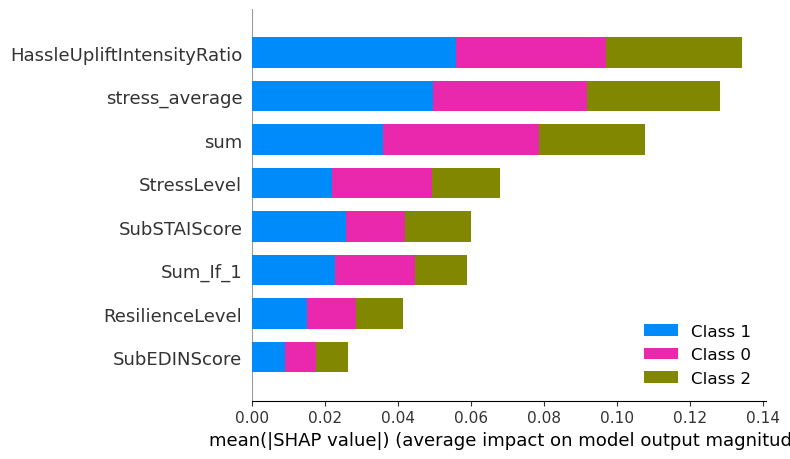

In [89]:
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)


In [99]:
y = pd.read_csv('outcome.csv')

In [106]:
# y = y.drop(['MH_outcome','V4AH01'],axis=1)
y = y.drop(['Birth_Type'], axis=1)


In [108]:
y

,PublicID,Birth_Weight_Category,CBAA04a,CBAA04b,Preterm_Birth_Category
0,00004O,3.0,8,9,3
1,00007I,3.0,9,9,3
2,00008G,3.0,8,9,3
3,00015J,3.0,9,9,3
4,00016H,3.0,3,8,3
...,...,...,...,...,...
7785,17349I,NaN,6,8,3
7786,17350A,2.0,7,9,2
7787,17351V,3.0,9,9,3
7788,17352T,3.0,9,9,3
